In [2]:
import pandas as pd
import json
import sys
from pathlib import Path
from helper import *
import joblib
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

/home/costanza/miniconda3/envs/mil/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing C23 - RWD
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/model_RF.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/train_set.xlsx')}, 'rwd_only': None}
Processing C23 - RWD_DP
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/model_LR.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/train_set.xlsx')}, 'rwd_only': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/rwd-only/results.xlsx'), 'pred

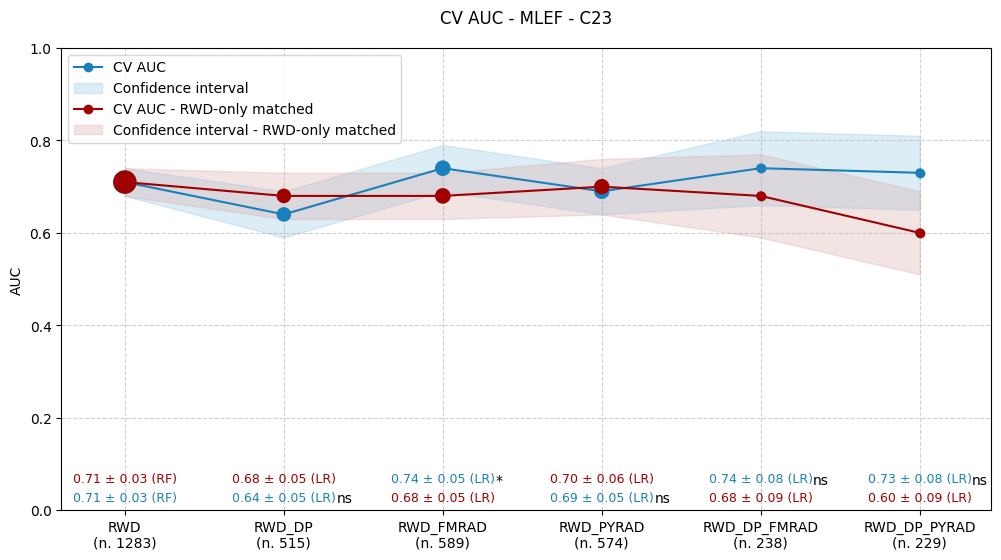

In [ ]:
plot_auc_results(
    architecture="MLEF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

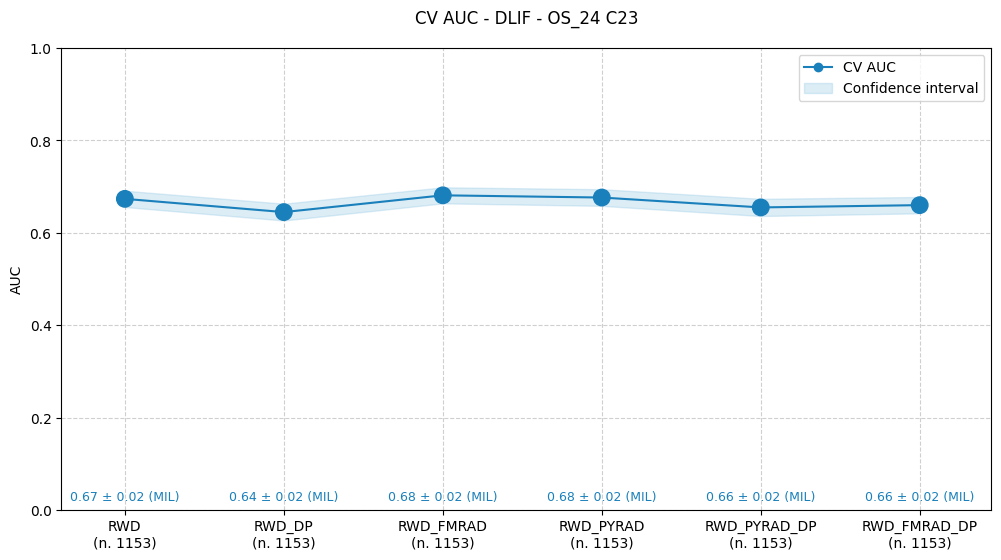

In [6]:
plot_auc_results(
    architecture="DLIF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

# BIOMARKER COMPARISON SPIDER PLOT

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [19]:
rwd = pd.read_csv('data/rwd.csv')
outcome = 'OS_24' #or 'OS_6' or 'DCR'
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
with open('mlef_pipeline/split.json', 'r') as f:
    split = json.load(f)
test = rwd[rwd['Subject'].isin(split['TEST_SET'])]
test = test[test[outcome].notna()].reset_index(drop=True)
y_pred_mlef = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/prediction_test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/rwd.csv'

In [ ]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,TN,0.0,FP,1.0,FP,1.0,FP,1.0
4,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
221,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
222,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
223,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
224,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0


In [6]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [ ]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing model on n. {len(bio)} patients...")
    
    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values

    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


In [ ]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.set_index('Subject').loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")

In [ ]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))


In [ ]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]
size = [
    results['binary' + bio_pdl1]['n.patients'],
    results['binary_BIO_NLR']['n.patients'],
    results['binary_BIO_LDH']['n.patients'],
    results['binary_BIO_ECOG']['n.patients']
]

In [49]:
# Load DLIF model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

predictions_df = pd.read_parquet('dlif_pipeline/results/C23/DCR/classification/standard/hypothesis_driven/pyrad-noimp/rwd_radfm_dp/seed_0/eval/00000-mb_attention_mil/predictions.parquet')

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



Loaded predictions for 273 patients
AUC from loaded predictions: 0.6495


In [ ]:
# Set up data from DLIF pipeline
rwd = pd.read_csv('data/rwd.csv')
# outcome = 'OS_24' #or 'OS_6' or 'DCR' --> convert to DLIF format
if outcome == 'OS_24' or outcome == 'os_months_24':
    dlif_outcome = 'os_months_24'
elif outcome == 'OS_6' or outcome == 'os_months_6':
    dlif_outcome = 'os_months_6'
elif outcome == 'DCR':
    dlif_outcome = 'DCR'

outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
# rwd = pd.read_csv('dlif_pipeline/data/rwd_outcomes.csv') # TODO Test with lines 11 and 12 instead of 13 for final submission
annotations = pd.read_csv('dlif_pipeline/data/annotations.csv')
outcome_col_name = "dataset_" + dlif_outcome
test_set = annotations[annotations[outcome_col_name]=='test']['slide'].tolist()

test = rwd[rwd['Subject'].isin(test_set)]
test = test[test[outcome].notna()].reset_index(drop=True)
y_pred_dlif = pd.read_parquet(f'dlif_pipeline/results/C23/{dlif_outcome}/classification/standard/hypothesis_driven/pyrad-noimp/rwd/seed_0/eval/00000-mb_attention_mil/predictions.parquet')
test

,Subject,AGE_AT_DIAGNOSIS,AGE_AT_IO_START,GENDER_F,EVER_SMOKED,C94_SMOKING_FORMER,C94_SMOKING_NEVER,SMOKING_PACKYEAR_CUTOFF_10,PFS_MONTHS,TTF_MONTHS,...,PDL1_CATHEGORY,PDL1_CONTINUOUS,ORR,CBR,DCR,os_months_6,os_months_24,PDL1 CATEGORY,LDH,ECOG PS
0,GHD1030052,50.391781,50.583562,1,0.0,0.0,1.0,0.0,2.923784,2.036794,...,2.0,70.0,0.0,0.0,0.0,1.0,0.0,2.0,638.0,NaN
1,GHD1030058,70.164384,70.254795,0,1.0,1.0,0.0,NaN,8.212878,3.942181,...,2.0,70.0,0.0,0.0,0.0,1.0,0.0,2.0,231.0,NaN
2,GHD1030060,75.482192,75.531507,1,1.0,0.0,0.0,1.0,1.905388,1.314060,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,173.0,NaN
3,GHD1030062,59.312329,59.679452,1,1.0,0.0,0.0,1.0,2.956636,2.431012,...,1.0,40.0,0.0,0.0,0.0,1.0,0.0,1.0,198.0,1.0
4,GHD1030064,48.402740,48.487671,0,1.0,1.0,0.0,0.0,5.486202,5.847569,...,1.0,7.0,1.0,1.0,1.0,1.0,0.0,1.0,167.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,VHIO1020160,64.205479,66.602740,0,1.0,0.0,0.0,1.0,1.018397,0.361367,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
222,VHIO1020164,71.427397,71.128767,0,1.0,0.0,0.0,1.0,0.788436,0.459921,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0
223,VHIO1020166,52.953425,53.958904,0,1.0,0.0,0.0,1.0,1.084100,0.886991,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
224,VHIO1020173,58.539726,58.846575,0,1.0,1.0,0.0,0.0,114.816032,109.296978,...,2.0,99.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN,1.0


In [47]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
print("test_biomarkers columns:", test_biomarkers.columns.tolist())
print("biomarkers list:", biomarkers)

test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

test_biomarkers columns: ['Subject', 'AGE_AT_DIAGNOSIS', 'AGE_AT_IO_START', 'GENDER_F', 'EVER_SMOKED', 'C94_SMOKING_FORMER', 'C94_SMOKING_NEVER', 'SMOKING_PACKYEAR_CUTOFF_10', 'PFS_MONTHS', 'TTF_MONTHS', 'OS_MONTHS', 'NSCLC_HISTOLOGY_SQUAMOUS', 'LAB22_LDH_BASAL', 'NLR', 'CF03_ECOG_BASAL', 'PDL1_CATHEGORY', 'PDL1_CONTINUOUS', 'ORR', 'CBR', 'DCR', 'os_months_6', 'os_months_24', 'PDL1 CATEGORY', 'LDH', 'ECOG PS', 'BIO_PDL1_1', 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
biomarkers list: ['BIO_PDL1_1', 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']


,BIO_PDL1_1,binary_BIO_PDL1_1,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,FP,1.0,FP,1.0,FP,1.0,FP,1.0
4,FP,1.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
221,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
222,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
223,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
224,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0


In [61]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_1:
AUC: 0.4698, Accuracy: 0.3977, Sensitivity: 0.6222, Specificity: 0.3175

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [54]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")

Testing DLIF model on n. 171 patients...
DLIF Metrics for binary_BIO_PDL1_1:
AUC: 0.6114, Accuracy: 0.5824, Sensitivity: 0.6082, Specificity: 0.5479

Testing DLIF model on n. 200 patients...
DLIF Metrics for binary_BIO_NLR:
AUC: 0.6123, Accuracy: 0.5800, Sensitivity: 0.5714, Specificity: 0.5909

Testing DLIF model on n. 154 patients...
DLIF Metrics for binary_BIO_LDH:
AUC: 0.6252, Accuracy: 0.5844, Sensitivity: 0.5952, Specificity: 0.5714

Testing DLIF model on n. 206 patients...
DLIF Metrics for binary_BIO_ECOG:
AUC: 0.6410, Accuracy: 0.6019, Sensitivity: 0.6033, Specificity: 0.6000



In [55]:

# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")


=== DeLong Test for binary_BIO_PDL1_1 vs DLIF Model ===
Biomarker AUC: 0.5303 (95% CI: 0.4579-0.6027)
DLIF Model AUC: 0.6114 (95% CI: 0.5258-0.6969)
AUC Difference: -0.0811
Z-score: -1.4796
P-value: 0.138972
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_NLR vs DLIF Model ===
Biomarker AUC: 0.5787 (95% CI: 0.5117-0.6458)
DLIF Model AUC: 0.6123 (95% CI: 0.5324-0.6923)
AUC Difference: -0.0336
Z-score: -0.7046
P-value: 0.481063
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_LDH vs DLIF Model ===
Biomarker AUC: 0.5869 (95% CI: 0.5192-0.6546)
DLIF Model AUC: 0.6252 (95% CI: 0.5352-0.7151)
AUC Difference: -0.0383
Z-score: -0.7361
P-value: 0.461684
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_ECOG vs DLIF Model ===
Biomarker AUC: 0.5

In [56]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))


=== DeLong Test Summary (DLIF) ===
Biomarker Biomarker_AUC  Biomarker_CI DLIF_Model_AUC DLIF_Model_CI AUC_Difference  P_value Significant  Better_Model
   PDL1_1         0.530 (0.458-0.603)          0.611 (0.526-0.697)         -0.081 0.138972          No No difference
      NLR         0.579 (0.512-0.646)          0.612 (0.532-0.692)         -0.034 0.481063          No No difference
      LDH         0.587 (0.519-0.655)          0.625 (0.535-0.715)         -0.038 0.461684          No No difference
     ECOG         0.599 (0.543-0.656)          0.641 (0.563-0.719)         -0.042 0.265901          No No difference


In [60]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_PDL1_1'].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}
p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_1', 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

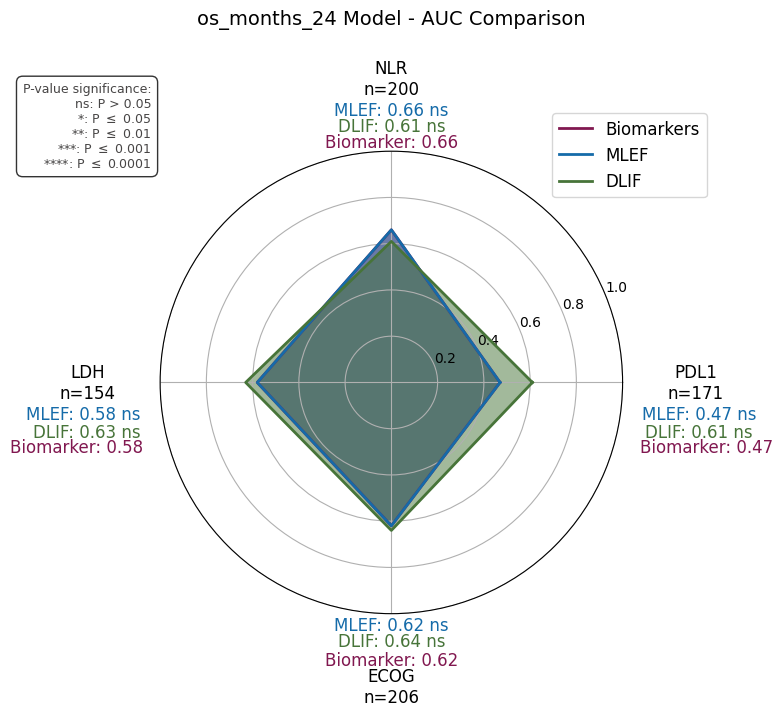

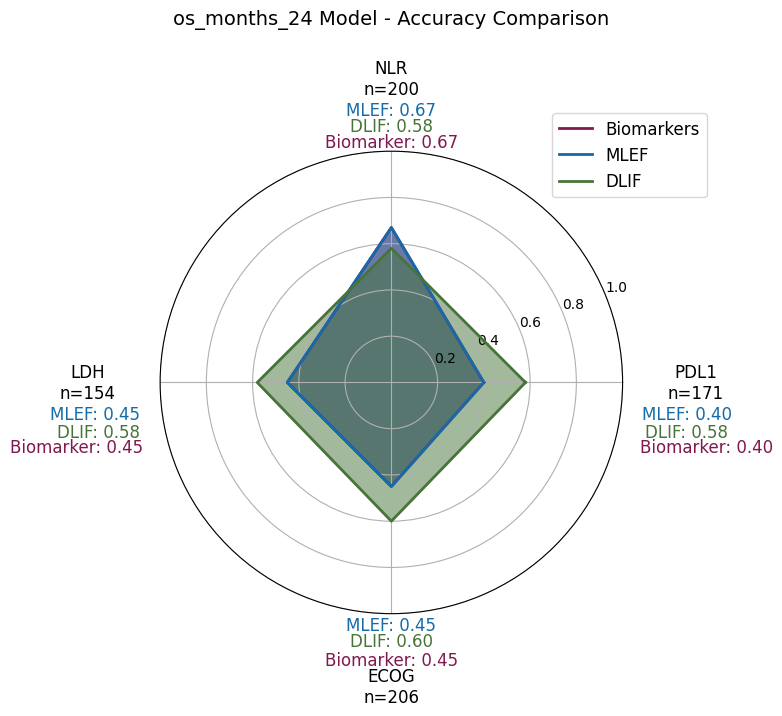

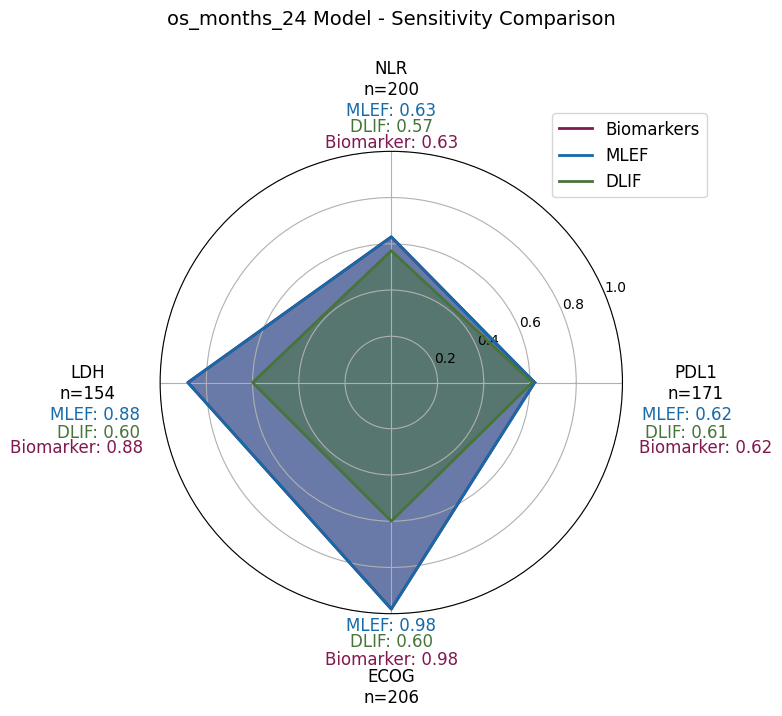

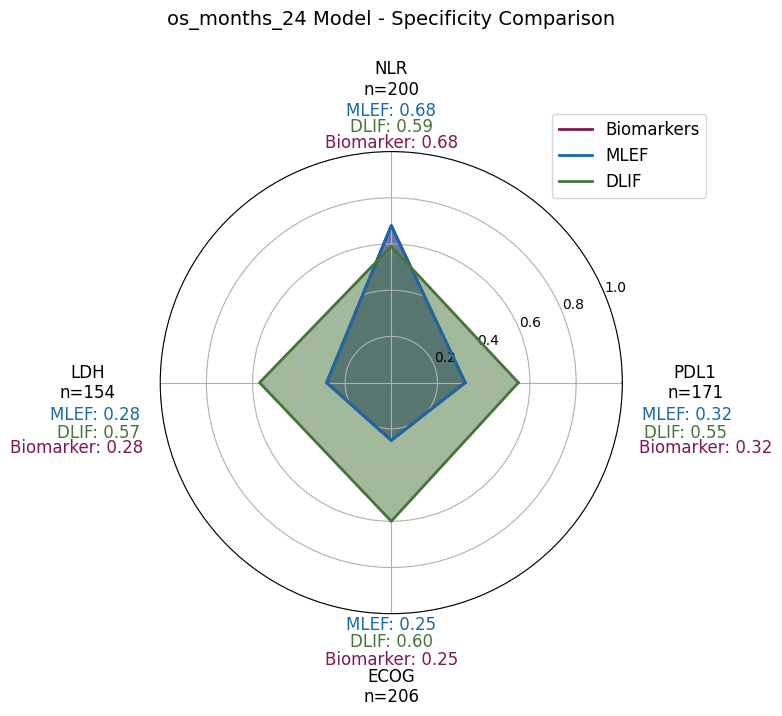

In [72]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
path = 'Biomarker_comparison'
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model'
)


# FARINESS RESULTS PLOT

In [73]:
from itertools import combinations

# ---------- utilities ----------
def _rate_by_group_conditional(df, group_col, cond_col, cond_val, pred_col='pred'):
    """Per-group rate Pr(pred==1 | cond_col==cond_val, group=g) and denominators."""
    sub = df[df[cond_col] == cond_val]
    if sub.empty:
        raise ValueError(f"No rows with {cond_col}=={cond_val}.")
    denom = sub.groupby(group_col).size().rename('denom')
    numer = sub[sub[pred_col] == 1].groupby(group_col).size().reindex(denom.index, fill_value=0)
    rate = (numer / denom).rename('rate')
    out = pd.concat([rate, denom], axis=1).reset_index().rename(columns={group_col: 'group'})
    return out

def _weighted_var_stat(rates_df):
    """Omnibus stat: sum w_g * (r_g - rbar)^2, w_g=denom."""
    w = rates_df['denom'].to_numpy()
    r = rates_df['rate'].to_numpy()
    if w.sum() == 0:
        return 0.0
    rbar = np.average(r, weights=w)
    return float(np.sum(w * (r - rbar)**2))

def _range_stat(rates_df):
    r = rates_df['rate'].to_numpy()
    return float(r.max() - r.min())

def _permute_groups_within_condition(df, group_col, cond_col, cond_val, rng):
    """Shuffle group labels only within rows where cond_col==cond_val (keeps base rates)."""
    sub_idx = df.index[df[cond_col] == cond_val]
    if len(sub_idx) == 0:
        return df
    shuffled = df.loc[sub_idx, group_col].to_numpy().copy()
    rng.shuffle(shuffled)
    out = df.copy()
    out.loc[sub_idx, group_col] = shuffled
    return out

# ---------- 1) Two-group permutation test (TPR & FPR) ----------
def permutation_test_two_groups(
    df,
    group_col='group',
    groups=('A','B'),
    pred_col='pred',
    actual_col='actual',
    n_perms=1000,
    n_boot=1000,
    ci_level=0.95,
    random_state=7
):
    """
    Returns observed diffs and permutation p-values for TPR and FPR between two groups.
    Also includes bootstrap CIs for each group's rates.
    TPR: shuffle within actual=1; FPR: shuffle within actual=0.
    """
    a, b = groups
    rng = np.random.default_rng(random_state)

    # helper to compute one metric (TPR or FPR) conditioned on cond_val
    def _obs_and_p(cond_val):
        sub = df[df[actual_col] == cond_val]
        if sub.empty:
            raise ValueError(f"No rows with {actual_col}=={cond_val}.")
        
        def _rate(g):
            gsub = sub[sub[group_col] == g]
            if gsub.empty:
                return np.nan, 0
            denom = len(gsub)
            numer = (gsub[pred_col] == 1).sum()
            return numer/denom, denom

        def _bootstrap_ci(g):
            """Bootstrap CI for a single group's rate"""
            gsub = sub[sub[group_col] == g]
            if gsub.empty or len(gsub) < 2:
                return np.nan, np.nan
            
            preds = gsub[pred_col].to_numpy()
            boot_rates = np.empty(n_boot)
            
            for i in range(n_boot):
                sample_idx = rng.choice(len(preds), size=len(preds), replace=True)
                boot_rates[i] = preds[sample_idx].mean()
            
            alpha = 1 - ci_level
            lower = np.percentile(boot_rates, 100 * alpha / 2)
            upper = np.percentile(boot_rates, 100 * (1 - alpha / 2))
            return lower, upper

        rA, nA = _rate(a)
        rB, nB = _rate(b)
        if np.isnan(rA) or np.isnan(rB):
            raise ValueError(f"One of the groups {groups} has no data under condition {cond_val}.")
        obs_diff = rA - rB

        # Get bootstrap CIs
        ci_A_lower, ci_A_upper = _bootstrap_ci(a)
        ci_B_lower, ci_B_upper = _bootstrap_ci(b)

        # build perm null: shuffle group labels within the condition
        diffs = np.empty(n_perms, dtype=float)
        labels = sub[group_col].to_numpy()
        
        for i in range(n_perms):
            shuffled = labels.copy()
            rng.shuffle(shuffled)
            A_idx = (shuffled == a)
            B_idx = (shuffled == b)
            rA_p = (sub[pred_col].to_numpy()[A_idx].mean() if A_idx.any() else np.nan)
            rB_p = (sub[pred_col].to_numpy()[B_idx].mean() if B_idx.any() else np.nan)
            diffs[i] = rA_p - rB_p

        p_two_sided = (np.sum(np.abs(diffs) >= abs(obs_diff)) + 1) / (n_perms + 1)
        
        return {
            'rate_A': rA, 'n_A': nA,
            'ci_A': (ci_A_lower, ci_A_upper),
            'rate_B': rB, 'n_B': nB,
            'ci_B': (ci_B_lower, ci_B_upper),
            'obs_diff': obs_diff,
            'p_value': p_two_sided
        }

    # TPR (condition on positives) and FPR (condition on negatives)
    out_tpr = _obs_and_p(cond_val=1)  # TPR
    out_fpr = _obs_and_p(cond_val=0)  # FPR

    return {'TPR': out_tpr, 'FPR': out_fpr}


# ---------- 2) K-group (e.g., 5 groups) omnibus + pairwise max-T ----------
def omnibus_and_pairs(
    df,
    group_col='group',
    pred_col='pred',
    actual_col='actual',
    cond_val=1,
    n_perms=1000,
    n_boot=1000,
    ci_level=0.95,
    random_state=42,
    stat='weighted_var',
    use_maxT=True
):
    rng = np.random.default_rng(random_state)

    # observed per-group rates
    obs_rates = _rate_by_group_conditional(df, group_col, actual_col, cond_val, pred_col)
    if stat == 'weighted_var':
        obs_stat = _weighted_var_stat(obs_rates)
    elif stat == 'range':
        obs_stat = _range_stat(obs_rates)
    else:
        raise ValueError("stat must be 'weighted_var' or 'range'.")

    # compute bootstrap CIs for each group
    def _bootstrap_ci_group(group_name):
        """Bootstrap CI for a single group's rate"""
        sub = df[df[actual_col] == cond_val]
        gsub = sub[sub[group_col] == group_name]
        
        if gsub.empty or len(gsub) < 2:
            return np.nan, np.nan
        
        preds = gsub[pred_col].to_numpy()
        boot_rates = np.empty(n_boot)
        
        for i in range(n_boot):
            sample_idx = rng.choice(len(preds), size=len(preds), replace=True)
            boot_rates[i] = preds[sample_idx].mean()
        
        alpha = 1 - ci_level
        lower = np.percentile(boot_rates, 100 * alpha / 2)
        upper = np.percentile(boot_rates, 100 * (1 - alpha / 2))
        return lower, upper

    # add CIs to obs_rates
    ci_lower = []
    ci_upper = []
    for g in obs_rates['group']:
        lower, upper = _bootstrap_ci_group(g)
        ci_lower.append(lower)
        ci_upper.append(upper)
    
    obs_rates['ci_lower'] = ci_lower
    obs_rates['ci_upper'] = ci_upper

    groups = obs_rates['group'].tolist()
    pairs = list(combinations(groups, 2))
    rate_map = dict(zip(obs_rates['group'], obs_rates['rate']))
    obs_pair_diffs = {pair: abs(rate_map[pair[0]] - rate_map[pair[1]]) for pair in pairs}

    # permutation nulls
    stat_null = np.empty(n_perms, dtype=float)
    max_pair_null = np.empty(n_perms, dtype=float) if use_maxT else None

    for i in range(n_perms):
        perm_df = _permute_groups_within_condition(df, group_col, actual_col, cond_val, rng)
        perm_rates = _rate_by_group_conditional(perm_df, group_col, actual_col, cond_val, pred_col)
        stat_null[i] = _weighted_var_stat(perm_rates) if stat == 'weighted_var' else _range_stat(perm_rates)

        if use_maxT:
            prm_map = dict(zip(perm_rates['group'], perm_rates['rate']))
            max_pair_null[i] = max(abs(prm_map[a] - prm_map[b]) for a, b in pairs)

    # omnibus p-value (right-tailed)
    p_omni = (np.sum(stat_null >= obs_stat) + 1) / (n_perms + 1)

    results = {
        'observed_rates': obs_rates.sort_values('group').reset_index(drop=True),
        'omnibus_stat': obs_stat,
        'omnibus_pvalue': p_omni,
    }

    # pairwise adjusted p-values (max-T)
    if use_maxT:
        pair_rows = []
        for (a, b), d in obs_pair_diffs.items():
            p_adj = (np.sum(max_pair_null >= d) + 1) / (n_perms + 1)
            pair_rows.append({'group_a': a, 'group_b': b, 'abs_diff': d, 'pvalue_maxT': p_adj})
        results['pairwise'] = pd.DataFrame(pair_rows).sort_values(['pvalue_maxT', 'abs_diff'], ascending=[True, False])

    # include raw nulls if you want to plot later
    results['null_stat'] = stat_null
    if use_maxT:
        results['null_max_pair_diff'] = max_pair_null

    return results


def permutation_fairness_TPR(df, **kw):
    """K-group omnibus + pairwise (maxT) for TPR (condition on actual=1)."""
    return omnibus_and_pairs(df, cond_val=1, **kw)


def permutation_fairness_FPR(df, **kw):
    """K-group omnibus + pairwise (maxT) for FPR (condition on actual=0)."""
    return omnibus_and_pairs(df, cond_val=0, **kw)

# compute TPR and FPR by race
from sklearn.metrics import confusion_matrix
def compute_tpr_fpr_race(y_true, y_pred):
	cm = confusion_matrix(y_true, y_pred)
	tn, fp, fn, tp = cm.ravel()
	tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
	fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
	
	return tpr, fpr


In [81]:
#split test set by center and calculate TPR and FPR
def split_by_center(index, sites: list[str]) -> pd.Series:
    test_folds = pd.Series(index=index, data=[next((site for site in sites if str(idx).lower().startswith(site.lower())), None) for idx in index])
    return test_folds
sites = ['INT', 'GHD', 'VHIO', 'MH', 'SZMC', 'UOC']
test_folds = split_by_center(test.index, sites)
test_folds

0      None
1      None
2      None
3      None
4      None
       ... 
221    None
222    None
223    None
224    None
225    None
Length: 226, dtype: object

In [75]:
# compute TPR and FPR by center
from sklearn.metrics import confusion_matrix
def compute_tpr_fpr(y_true, y_pred, test_folds):
    tpr_fpr = {}
    for site in test_folds.unique():
        if site is None:
            continue
        indices = test_folds == site
        cm = confusion_matrix(y_true[indices], y_pred[indices] >= 0.5)
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        tpr_fpr[site] = {'TPR': tpr, 'FPR': fpr}
    return pd.DataFrame(tpr_fpr).T
os24_tpr_fpr = compute_tpr_fpr(y_test, y_pred, test_folds)
os24_tpr_fpr

NameError: name 'y_test' is not defined

In [ ]:
#create a df with columns: group, pred, actual
df_os24 = pd.DataFrame({'center': test_folds, 'sex':test['GENDER_M'], 'pred': (y_pred > 0.5).astype(int), 'actual': y_test})
df_os24
# --- Two groups (e.g., 'A' vs 'B') ---
os24_sex_fair = permutation_test_two_groups(df_os24, group_col='sex', groups=df_os24['sex'].unique(), n_perms=1000, random_state=42)
print("Two-group TPR:", os24_sex_fair['TPR'])
print("Two-group FPR:", os24_sex_fair['FPR'])

# --- Five groups (omnibus + pairwise) ---
os24_tpr_out = permutation_fairness_TPR(df_os24, group_col='center', n_perms=1000, stat='weighted_var', random_state=42)
print("\nTPR omnibus p:", os24_tpr_out['omnibus_pvalue'])
print(os24_tpr_out['observed_rates'])
print(os24_tpr_out['pairwise'])  # needs use_maxT=True (default)

os24_fpr_out = permutation_fairness_FPR(df_os24, group_col='center', n_perms=1000, stat='weighted_var', random_state=42)
print("\nFPR omnibus p:", os24_fpr_out['omnibus_pvalue'])
print(os24_fpr_out['observed_rates'])
print(os24_fpr_out['pairwise'])


# GLOBAL XAI

In [ ]:
outcome = 'DCR' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/model_LR.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)

In [ ]:
outcome = 'DCR' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/model_LR.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)